In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


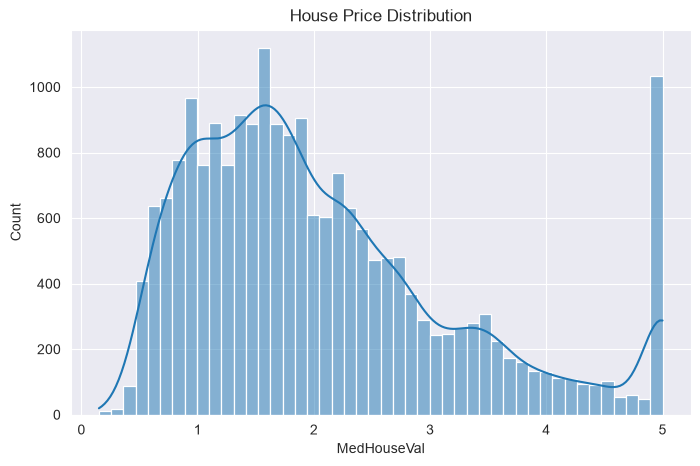

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MedHouseVal"],
    kde=True
)

plt.title("House Price Distribution")
plt.show()

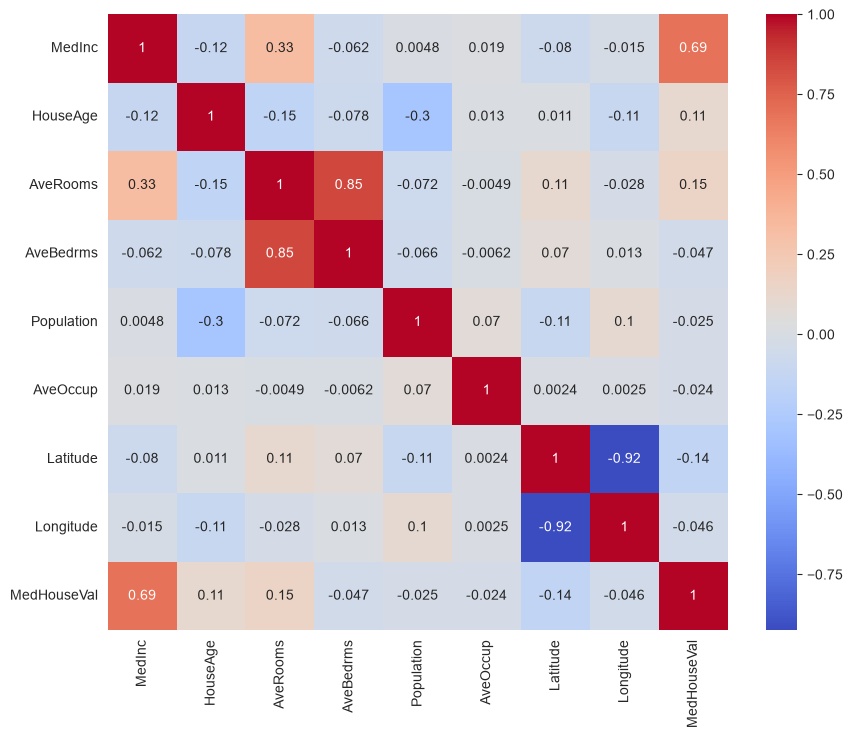

In [9]:
corr = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [11]:
corr["MedHouseVal"].sort_values(
    ascending=False
)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

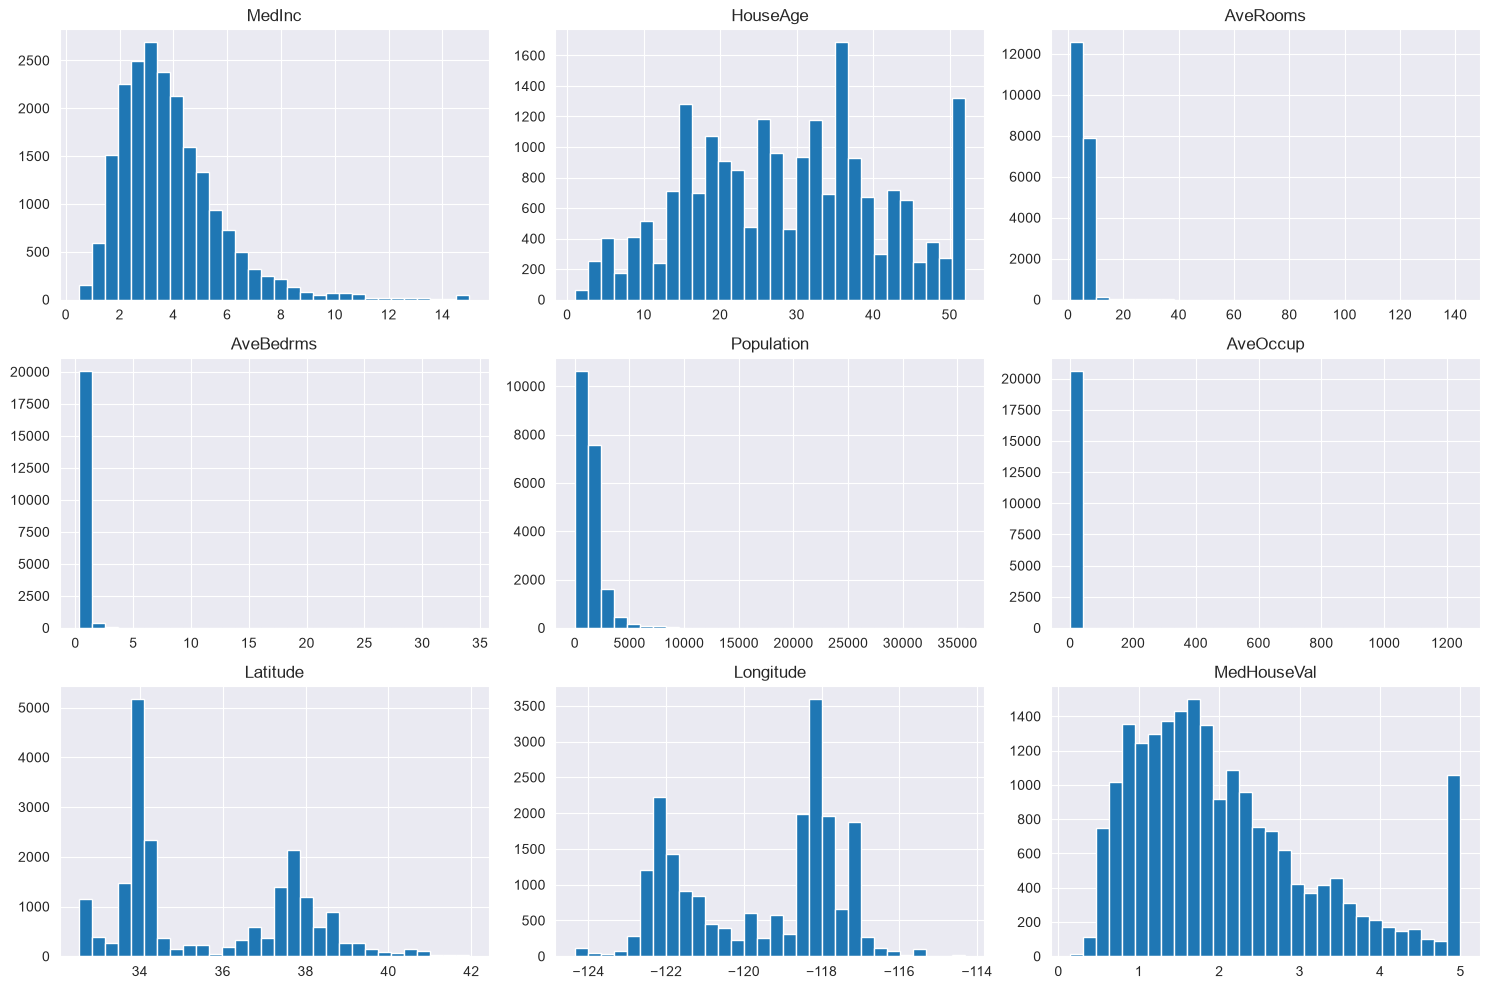

In [12]:
df.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

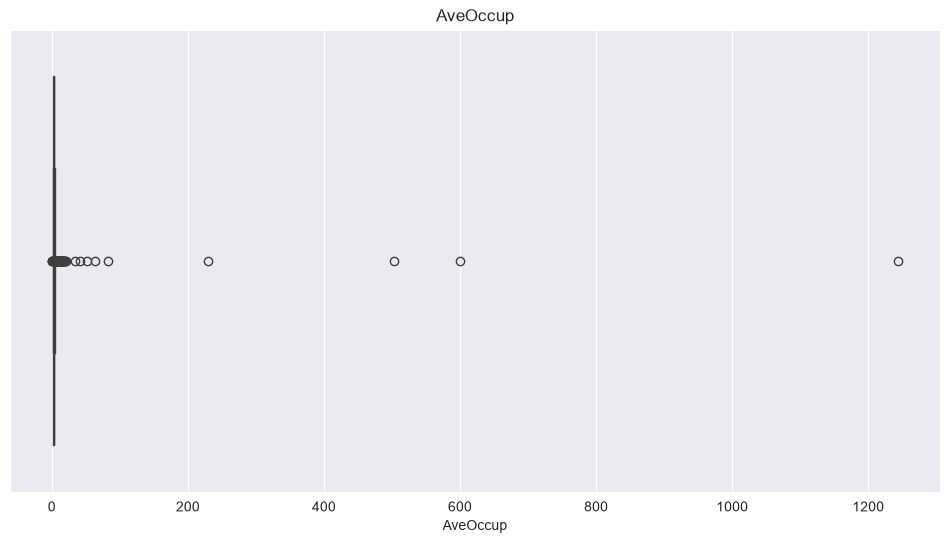

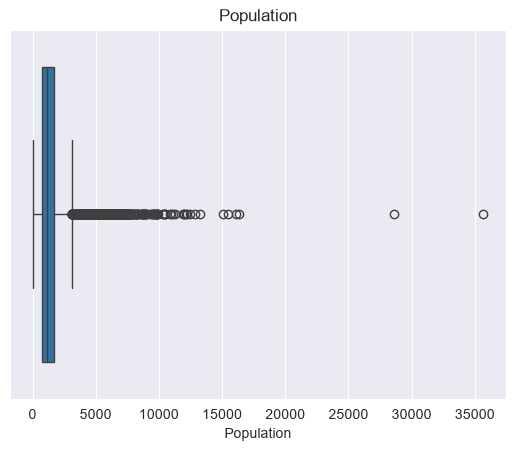

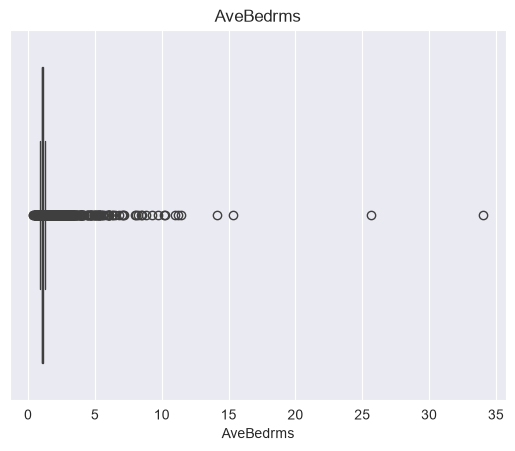

In [13]:
outlier_cols = [
    "AveOccup",
    "Population",
    "AveBedrms"
]

plt.figure(figsize=(12,6))

for col in outlier_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
df['RoomsPerBedroom'] = (
    df['AveRooms'] / df['AveBedrms']
)

df['IncomePerOccupant'] = (
    df['MedInc'] / df['AveOccup']
)

df['PopulationDensity'] = (
    df['Population'] / df['AveOccup']
)

df["Population_log"] = np.log1p(df["Population"])

df["AveOccup_log"] = np.log1p(df["AveOccup"])

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [22]:
X = df.drop(['MedHouseVal'], axis=1)

y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R^2 :", r2)

MSE : 0.44778154882951127
MAE : 0.48278976974902693
RMSE : 0.6691648143988977
R^2 : 0.6582887050799853


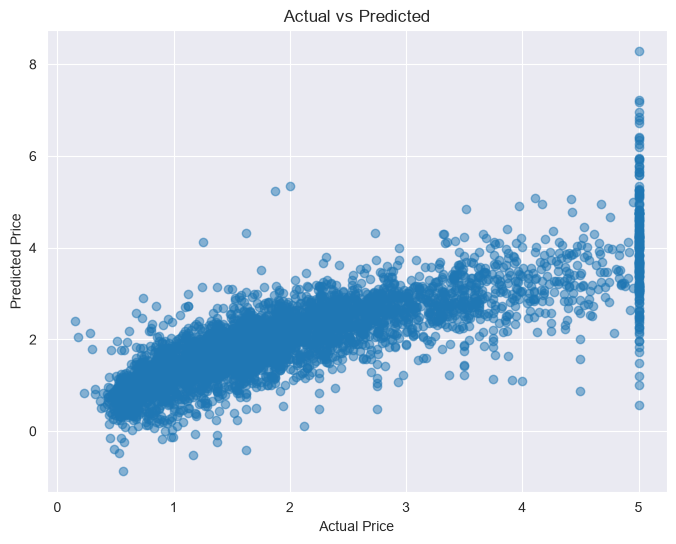

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [31]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R^2 :", r2)

MSE : 0.44780966895889834
MAE : 0.48280401933673583
RMSE : 0.669185825431844
R^2 : 0.6582672460318149


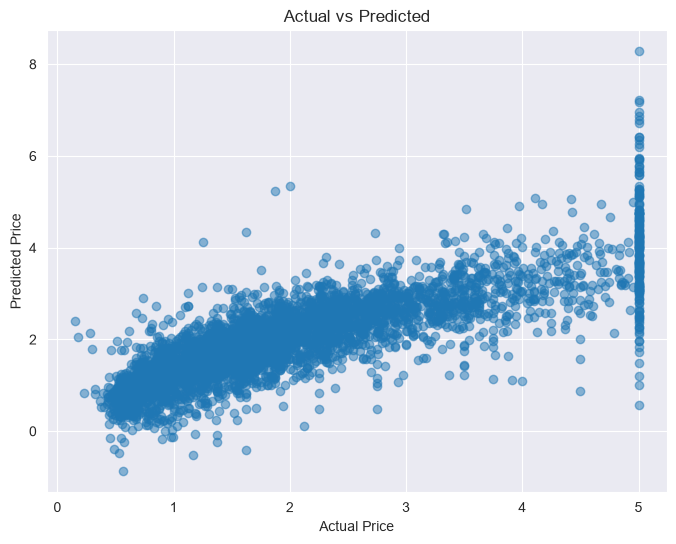

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [33]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R^2 :", r2)

MSE : 0.875308187776761
MAE : 0.732766957671135
RMSE : 0.93557906548659
R^2 : 0.33203434781729013


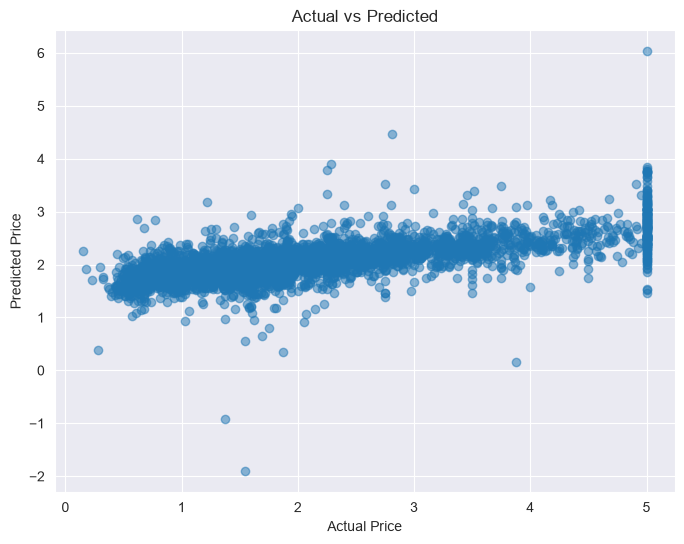

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [35]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R^2 :", r2)

MSE : 0.23559062479198029
MAE : 0.31082059109453003
RMSE : 0.48537678641647075
R^2 : 0.820215956465562


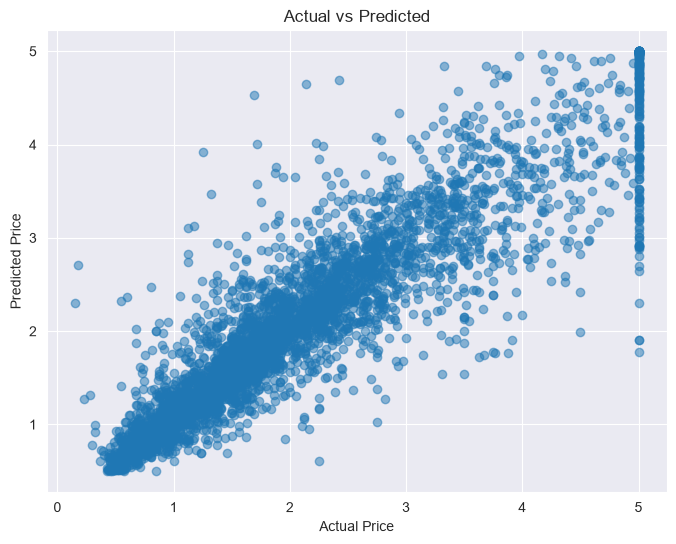

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
9   IncomePerOccupant    0.624083
7           Longitude    0.103502
6            Latitude    0.096743
1            HouseAge    0.034690
0              MedInc    0.029741
8     RoomsPerBedroom    0.019408
3           AveBedrms    0.018760
2            AveRooms    0.018139
5            AveOccup    0.013226
12       AveOccup_log    0.013054
10  PopulationDensity    0.011347
11     Population_log    0.008655
4          Population    0.008653


In [38]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R^2 :", r2)

MSE : 0.22476054164452614
MAE : 0.31142012199463537
RMSE : 0.47408917056238076
R^2 : 0.8284806153066457


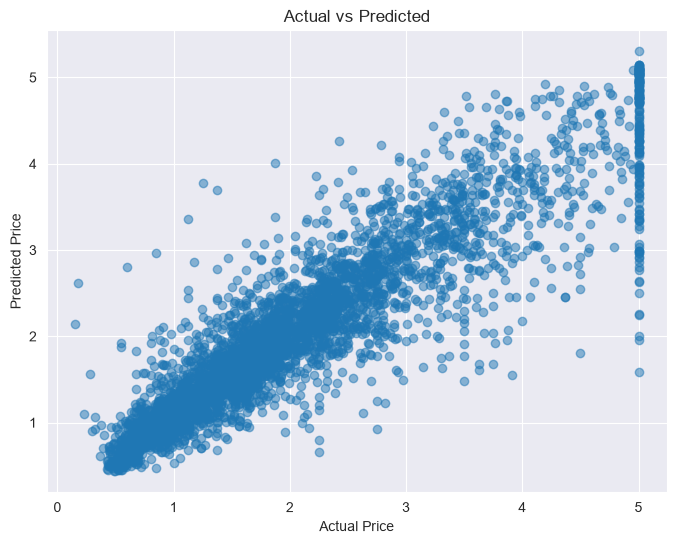

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

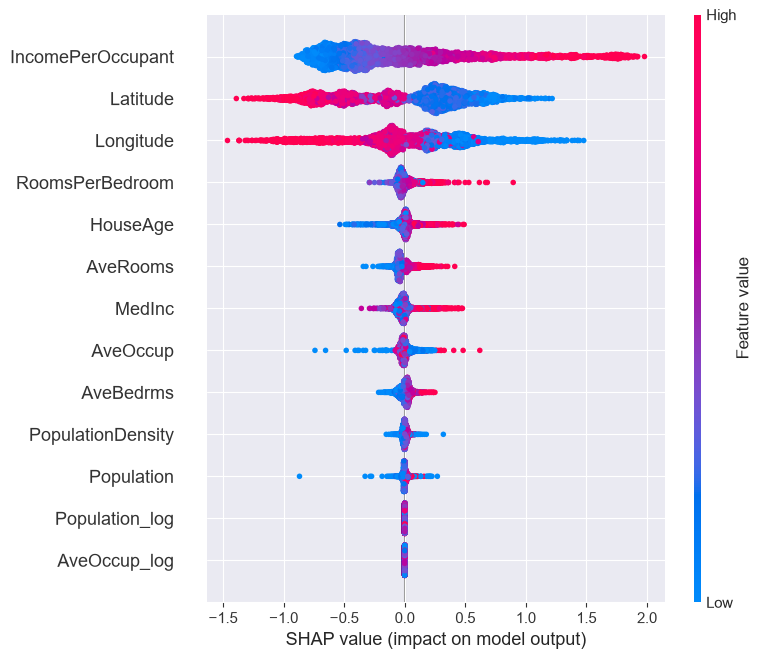

In [43]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test
)

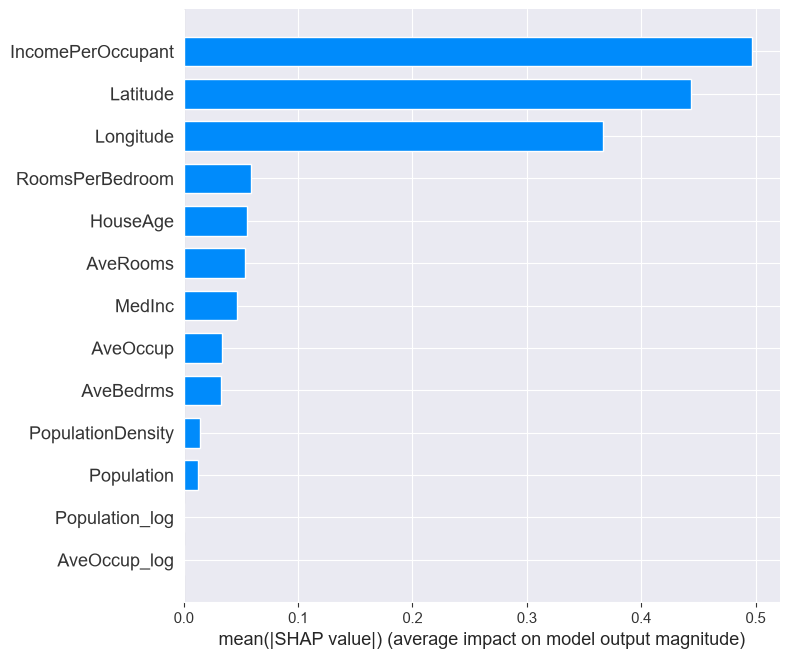

In [44]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [45]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

              Feature  Importance
9   IncomePerOccupant    0.496592
6            Latitude    0.443512
7           Longitude    0.366626
8     RoomsPerBedroom    0.058624
1            HouseAge    0.054909
2            AveRooms    0.053953
0              MedInc    0.046733
5            AveOccup    0.033485
3           AveBedrms    0.032640
10  PopulationDensity    0.014080
4          Population    0.012185
11     Population_log    0.000000
12       AveOccup_log    0.000000
